Koden laddar först in företagets personaldata och räknar snabbt ut den exakta procentandelen av hur många som har slutat. Därefter skapar den två visuella diagram: ett stapeldiagram som jämför hur många som slutar uppdelat på olika lönenivåer, och ett låddiagram som visar skillnaden i trivsel mellan de som är kvar och de som har lämnat. Syftet är att ge en snabb visuell överblick över om lön eller missnöje driver personalomsättningen.

# Personalomsättning Överblick
**Insats till Ledningsgruppen**

Här är en snabbanalys av vår personaldata för att svara på tre enkla frågor:
1. Hur många slutar?
2. Slutar folk på grund av lönen?
3. Slutar folk på grund av dålig trivsel?

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Läs in datan
df = pd.read_excel("hr_employee_data.xlsx")
#df = pd.read_csv('hr_employee_data.xlsx')

# Beräkna hur många procent som slutat
andel_slutat = df['left'].value_counts(normalize=True) * 100
print("Procentuell fördelning (0 = Kvar, 1 = Slutat):")
print(andel_slutat.round(1))

Procentuell fördelning (0 = Kvar, 1 = Slutat):
left
0    76.2
1    23.8
Name: proportion, dtype: float64


## 1. Slutar personalen på grund av lönen?
Grafen nedan visar hur många som stannar (blå) jämfört med hur många som slutar (orange), uppdelat på lönenivå.

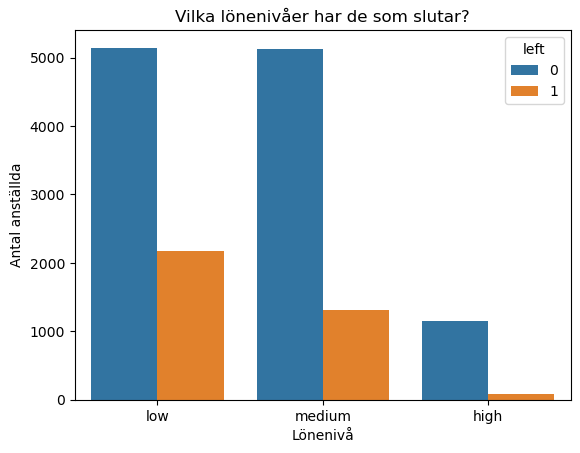

In [16]:
# Skapa ett enkelt stapeldiagram
sns.countplot(data=df, x='salary', hue='left')
plt.title('Vilka lönenivåer har de som slutar?')
plt.xlabel('Lönenivå')
plt.ylabel('Antal anställda')
plt.show()

## 2. Slutar personalen för att de vantrivs?
Här ser vi trivselnivån ("satisfaction_level"). Den vänstra lådan visar de som är kvar, den högra visar de som har slutat.

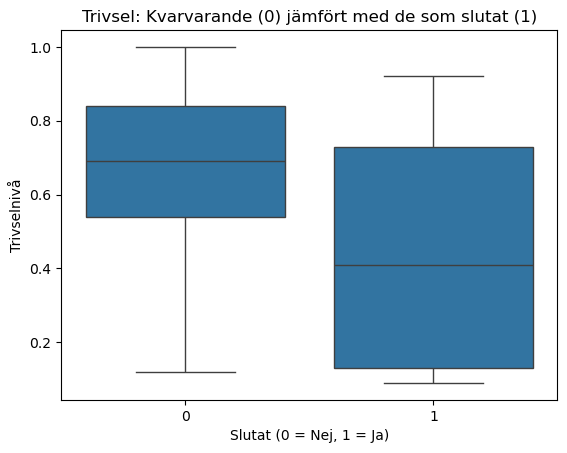

In [17]:
# Skapa ett låddiagram för att visa trivsel
sns.boxplot(data=df, x='left', y='satisfaction_level')
plt.title('Trivsel: Kvarvarande (0) jämfört med de som slutat (1)')
plt.xlabel('Slutat (0 = Nej, 1 = Ja)')
plt.ylabel('Trivselnivå')
plt.show()

## Kort Slutsats
Vi tappar personal på grund av en kombination av låg trivsel och otillräckliga löner. Det finns ett tydligt samband där de som lämnar företaget har en markant lägre nöjdhetsnivå (median på 0,4 mot de kvarvarandes 0,7) och gruppen med låga löner visar tecken på storre vilja att lämna.

**Rekommendation:** Översyn och höjning av de lägsta lönerna är det mest direkta sättet att få folk att stanna. Identifiera vilka avdelningar som har lägst trivsel och starta en dialog med de anställda där innan de väljer att gå vidare. 